# Capacitated VRP with a Hybrid Genetic Algorithm

This notebook implements a Hybrid Genetic Algorithm (GA + 2-opt local search) for Capacitated VRP and evaluates it on CVRPLIB sets E, F, M, P.


## Assignment Checklist

1. Metaheuristic algorithm: Hybrid Genetic Algorithm (GA + 2-opt).
2. Parameters and stopping criterion: defined in the experiment cell.
3. Experiments: all instances from sets E, F, M, P (CVRPLIB).
4. Analysis: quality and speed vs. problem size and set type.
5. Slides: outline provided at the end.


In [47]:
import sys
import subprocess
import importlib

# Ensure required packages (works in local Jupyter and Colab)
for pkg in ["matplotlib", "scipy", "pandas"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import time
from pathlib import Path


In [48]:
from pathlib import Path
import subprocess
import importlib
import sys

archives = ["E.7z", "F.7z", "M.7z", "P.7z"]

# Prefer system 7z if available; fallback to py7zr
use_py7zr = False
try:
    subprocess.run(["7z"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
except FileNotFoundError:
    use_py7zr = True

if use_py7zr:
    try:
        importlib.import_module("py7zr")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "py7zr"])
    import py7zr

for archive in archives:
    target_dir = Path(archive.replace(".7z", ""))
    if target_dir.exists():
        continue
    if use_py7zr:
        with py7zr.SevenZipFile(archive, mode="r") as z:
            z.extractall(path=target_dir)
        print(f"Extracted {archive} -> {target_dir}")
    else:
        subprocess.run(["7z", "x", archive], check=True)
        print(f"Extracted {archive} -> {target_dir}")


## Data Loading

We parse `.vrp` files, build coordinates, demands, capacity, and compute the distance matrix.


In [49]:
def parse_vrp_file(content: bytes):
    lines = content.decode("utf-8", errors="ignore").splitlines()
    section = None
    coords = []
    demands = []
    capacity = None

    for raw in lines:
        line = raw.strip()
        if not line:
            continue

        if line.startswith("CAPACITY"):
            capacity = int(line.split(":")[-1].strip())
            continue
        if line.startswith("NODE_COORD_SECTION"):
            section = "coords"
            continue
        if line.startswith("DEMAND_SECTION"):
            section = "demands"
            continue
        if line.startswith("DEPOT_SECTION") or line.startswith("EOF"):
            break

        parts = line.split()
        if section == "coords" and len(parts) >= 3:
            try:
                coords.append([float(parts[1]), float(parts[2])])
            except ValueError:
                pass
        elif section == "demands" and len(parts) >= 2:
            try:
                demands.append(int(parts[1]))
            except ValueError:
                pass

    if capacity is None:
        raise ValueError("Missing CAPACITY in VRP file.")
    if len(coords) == 0 or len(demands) == 0:
        raise ValueError("Failed to parse coordinates or demands.")

    coords = np.array(coords)
    demands = np.array(demands)
    dist = cdist(coords, coords)
    return {
        "coords": coords,
        "demands": demands,
        "capacity": capacity,
        "distance_matrix": dist,
    }


## Hybrid Genetic Algorithm (GA + 2-opt)

Representation: list of routes, each route is a list of customer indices (depot is index 0).


In [50]:
class VRPData:
    def __init__(self, coords, demands, capacity, distance_matrix):
        self.coords = coords
        self.demands = demands
        self.capacity = capacity
        self.distance_matrix = distance_matrix
        self.depot_index = 0
        self.num_customers = len(coords) - 1

class Solution:
    def __init__(self, routes, total_distance=None, fitness=None):
        self.routes = routes
        self.total_distance = total_distance
        self.fitness = fitness


def route_distance(route, data: VRPData):
    if not route:
        return 0.0
    dist = data.distance_matrix[data.depot_index, route[0]]
    for i in range(len(route) - 1):
        dist += data.distance_matrix[route[i], route[i + 1]]
    dist += data.distance_matrix[route[-1], data.depot_index]
    return dist


def fitness_function(solution: Solution, data: VRPData, penalty_factor=1000):
    total = 0.0
    penalty = 0.0
    for route in solution.routes:
        load = 0
        for node in route:
            load += data.demands[node]
        if load > data.capacity:
            penalty += (load - data.capacity)
        total += route_distance(route, data)

    solution.total_distance = total
    solution.fitness = total + penalty_factor * penalty
    return solution.fitness


def initialize_population(pop_size, data: VRPData):
    customers = list(range(1, data.num_customers + 1))
    population = []
    for _ in range(pop_size):
        remaining = customers[:]
        np.random.shuffle(remaining)
        routes = []
        while remaining:
            route = []
            load = 0
            to_remove = []
            for cust in remaining:
                if load + data.demands[cust] <= data.capacity:
                    route.append(cust)
                    load += data.demands[cust]
                    to_remove.append(cust)
            for cust in to_remove:
                remaining.remove(cust)
            if not route and remaining:
                cust = remaining.pop(0)
                route = [cust]
            routes.append(route)
        sol = Solution(routes)
        fitness_function(sol, data)
        population.append(sol)
    return population


def tournament_selection(population, k=3):
    selected = []
    for _ in range(len(population)):
        contenders = np.random.choice(population, k, replace=False)
        winner = min(contenders, key=lambda s: s.fitness)
        selected.append(winner)
    return selected


def flatten_routes(routes):
    flat = []
    for r in routes:
        flat.extend(r)
    return flat


def build_routes_from_permutation(permutation, data: VRPData):
    routes = []
    route = []
    load = 0
    for cust in permutation:
        demand = data.demands[cust]
        if load + demand <= data.capacity:
            route.append(cust)
            load += demand
        else:
            routes.append(route)
            route = [cust]
            load = demand
    if route:
        routes.append(route)
    return routes


def order_crossover(p1: Solution, p2: Solution, data: VRPData):
    a = flatten_routes(p1.routes)
    b = flatten_routes(p2.routes)
    size = len(a)
    cut1, cut2 = sorted(np.random.choice(range(size), 2, replace=False))

    child = [None] * size
    child[cut1:cut2] = a[cut1:cut2]

    b_remain = [x for x in b if x not in child]
    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = b_remain[idx]
            idx += 1

    routes = build_routes_from_permutation(child, data)
    sol = Solution(routes)
    fitness_function(sol, data)
    return sol


def swap_mutation(sol: Solution, data: VRPData, rate=0.1):
    if np.random.rand() >= rate:
        return sol
    flat = flatten_routes(sol.routes)
    if len(flat) < 2:
        return sol
    i, j = np.random.choice(range(len(flat)), 2, replace=False)
    flat[i], flat[j] = flat[j], flat[i]
    routes = build_routes_from_permutation(flat, data)
    new_sol = Solution(routes)
    fitness_function(new_sol, data)
    return new_sol


def two_opt(route, data: VRPData):
    best = route[:]
    improved = True
    while improved:
        improved = False
        for i in range(len(best) - 1):
            for j in range(i + 1, len(best)):
                cand = best[:i] + best[i:j+1][::-1] + best[j+1:]
                if route_distance(cand, data) < route_distance(best, data):
                    best = cand
                    improved = True
                    break
            if improved:
                break
    return best


def apply_two_opt(sol: Solution, data: VRPData):
    routes = []
    for r in sol.routes:
        if len(r) > 2:
            routes.append(two_opt(r, data))
        else:
            routes.append(r)
    new_sol = Solution(routes)
    fitness_function(new_sol, data)
    return new_sol


def hybrid_genetic_algorithm(
    data: VRPData,
    pop_size=50,
    num_generations=100,
    crossover_rate=0.8,
    mutation_rate=0.1,
    tournament_size=5,
    local_search_frequency=10,
):
    population = initialize_population(pop_size, data)
    population.sort(key=lambda s: s.fitness)
    best = population[0]

    for gen in range(num_generations):
        new_pop = [best]
        while len(new_pop) < pop_size:
            parents = tournament_selection(population, tournament_size)
            p1, p2 = np.random.choice(parents, 2, replace=False)

            if np.random.rand() < crossover_rate:
                child = order_crossover(p1, p2, data)
            else:
                child = p1

            child = swap_mutation(child, data, mutation_rate)
            if local_search_frequency > 0 and (gen + 1) % local_search_frequency == 0:
                child = apply_two_opt(child, data)

            new_pop.append(child)

        new_pop.sort(key=lambda s: s.fitness)
        population = new_pop[:pop_size]
        if population[0].fitness < best.fitness:
            best = population[0]

    return best


## Parameters and Stopping Criterion

- Parameters are defined in the experiment cell below.
- Stopping criterion: fixed number of generations (`num_generations`).


In [51]:
optimal_values = {
    # E-instances
    'E-n13-k4.vrp': 246.0,
    'E-n22-k4.vrp': 347.0,
    'E-n23-k3.vrp': 529.0,
    'E-n30-k3.vrp': 558.0,
    'E-n31-k7.vrp': 643.0,
    'E-n33-k4.vrp': 792.0,
    'E-n51-k5.vrp': 727.0,
    'E-n76-k7.vrp': 835.0,
    'E-n76-k8.vrp': 731.0,
    'E-n76-k10.vrp': 752.0,
    'E-n76-k14.vrp': 1021.0,
    'E-n101-k8.vrp': 1063.0,
    'E-n101-k14.vrp': 1121.0,

    # F-instances
    'F-n45-k4.vrp': 1205.0,
    'F-n72-k4.vrp': 1878.0,
    'F-n135-k7.vrp': 2390.0,

    # M-instances
    'M-n101-k10.vrp': 820.0,
    'M-n121-k7.vrp': 1039.0,
    'M-n151-k12.vrp': 1251.0,
    'M-n200-k16.vrp': 1718.0,
    'M-n200-k17.vrp': 1307.0,

    # P-instances
    'P-n16-k8.vrp': 450.0,
    'P-n19-k2.vrp': 214.0,
    'P-n20-k2.vrp': 208.0,
    'P-n21-k2.vrp': 212.0,
    'P-n22-k2.vrp': 210.0,
    'P-n22-k8.vrp': 603.0,
    'P-n23-k8.vrp': 626.0,
    'P-n40-k5.vrp': 458.0,
    'P-n45-k5.vrp': 475.0,
    'P-n50-k7.vrp': 529.0,
    'P-n50-k8.vrp': 558.0,
    'P-n50-k10.vrp': 584.0,
    'P-n51-k10.vrp': 598.0,
    'P-n55-k7.vrp': 622.0,
    'P-n55-k8.vrp': 647.0,
    'P-n55-k10.vrp': 664.0,
    'P-n55-k15.vrp': 823.0,
    'P-n60-k10.vrp': 694.0,
    'P-n60-k15.vrp': 876.0,
    'P-n65-k10.vrp': 737.0,
    'P-n70-k10.vrp': 764.0,
    'P-n76-k4.vrp': 709.0,
    'P-n76-k5.vrp': 734.0,
    'P-n101-k4.vrp': 945.0,
}


## Experiments (E, F, M, P)

We run the algorithm on each instance and compute the Gap % relative to the best-known optimal values.


In [52]:
# Diagnostic: count .vrp files in each folder (recursive)
for d in ["E", "F", "M", "P"]:
    path = Path(d)
    if not path.exists():
        print(f"{d}: folder not found")
        continue
    files = list(path.rglob("*.vrp"))
    print(f"{d}: {len(files)} .vrp files (recursive)")


E: 13 .vrp files (recursive)
F: 3 .vrp files (recursive)
M: 5 .vrp files (recursive)
P: 24 .vrp files (recursive)


In [53]:
params = {
    "pop_size": 50,
    "num_generations": 200,
    "crossover_rate": 0.8,
    "mutation_rate": 0.1,
    "tournament_size": 5,
    "local_search_frequency": 10,
}

vrp_dirs = ["E", "F", "M", "P"]
results = []
failed = []

for d in vrp_dirs:
    for name in sorted(Path(d).rglob("*.vrp")):
        with open(name, "rb") as f:
            content = f.read()
        try:
            parsed = parse_vrp_file(content)
        except ValueError as e:
            failed.append((str(name), str(e)))
            continue

        data = VRPData(parsed["coords"], parsed["demands"], parsed["capacity"], parsed["distance_matrix"])

        t0 = time.perf_counter()
        best = hybrid_genetic_algorithm(data, **params)
        t1 = time.perf_counter()

        best_cost = best.total_distance
        opt = optimal_values.get(name.name)
        gap = None
        if opt is not None:
            gap = 100.0 * (best_cost - opt) / opt

        results.append({
            "Instance Name": name.name,
            "Set": name.name[0],
            "Number of Customers": data.num_customers,
            "Best Distance": best_cost,
            "Optimal Distance": opt,
            "Gap %": gap,
            "Time (s)": t1 - t0,
        })

results_df = pd.DataFrame(results)

if failed:
    print("Parsing failures (showing up to 10):")
    for item in failed[:10]:
        print(item[0], "->", item[1])

if results_df.empty:
    print("No results collected. Check that E/F/M/P folders were extracted and contain .vrp files.")
else:
    if "Set" not in results_df.columns:
        results_df["Set"] = results_df["Instance Name"].str[0]
    results_df.sort_values(["Set", "Number of Customers"], inplace=True)

results_df.head()


Parsing failures (showing up to 10):
E/E/E-n13-k4.vrp -> Failed to parse coordinates or demands.
E/E/E-n31-k7.vrp -> Failed to parse coordinates or demands.


,Instance Name,Set,Number of Customers,Best Distance,Optimal Distance,Gap %,Time (s)
2,E-n22-k4.vrp,E,21,436.247443,347.0,25.719724,7.384537
3,E-n23-k3.vrp,E,22,573.200469,529.0,8.355476,8.265890
4,E-n30-k3.vrp,E,29,547.003270,558.0,-1.970740,9.312889
5,E-n33-k4.vrp,E,32,968.301884,792.0,22.260339,8.158524
6,E-n51-k5.vrp,E,50,723.446378,727.0,-0.488806,9.819746


## Analysis

- Quality vs. problem size: use Gap %.
- Speed vs. problem size: use Time (s).
- Compare instance sets E/F/M/P.


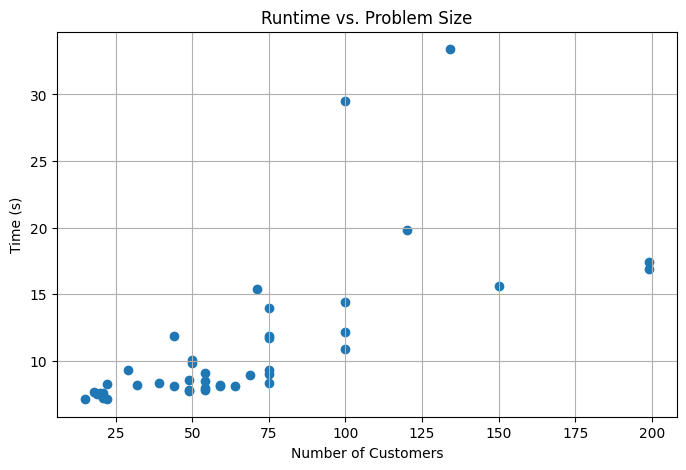

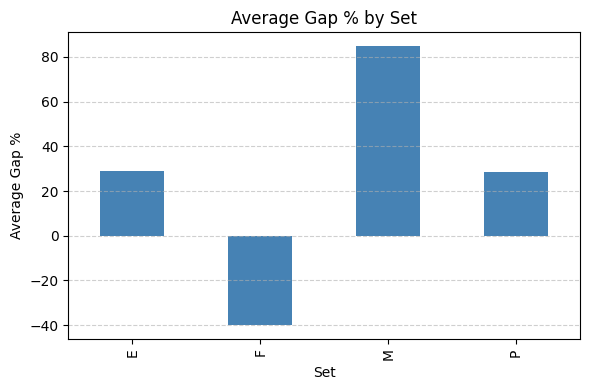

In [54]:
# Scatter: time vs. size
if results_df.empty:
    print("No results to plot. Run the experiment cell first.")
else:
    plt.figure(figsize=(8, 5))
    plt.scatter(results_df["Number of Customers"], results_df["Time (s)"])
    plt.xlabel("Number of Customers")
    plt.ylabel("Time (s)")
    plt.title("Runtime vs. Problem Size")
    plt.grid(True)
    plt.show()

    # Average gap per set
    avg_gap = results_df.groupby("Set")["Gap %"].mean()
    plt.figure(figsize=(6, 4))
    avg_gap.plot(kind="bar", color="steelblue")
    plt.xlabel("Set")
    plt.ylabel("Average Gap %")
    plt.title("Average Gap % by Set")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    avg_gap


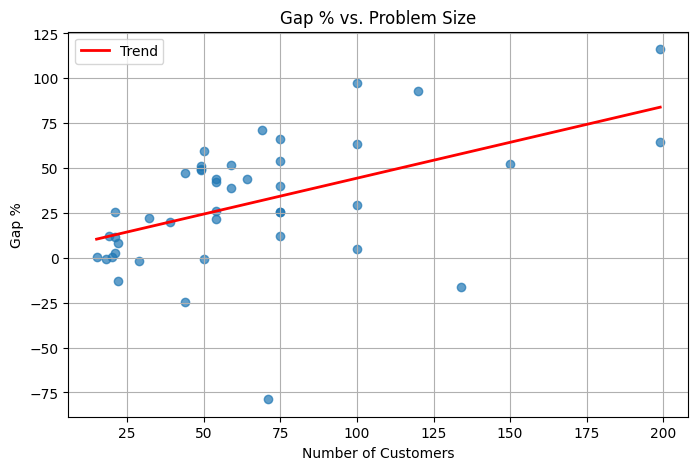

/var/folders/t1/7wl3rfv56q3_66scyjg0vqc40000gn/T/ipykernel_70429/3594829279.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sets, patch_artist=True)


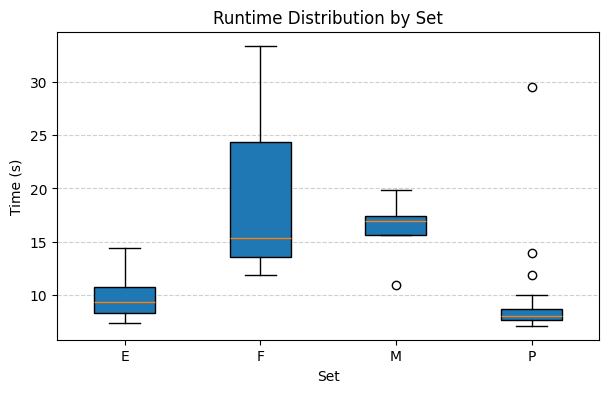

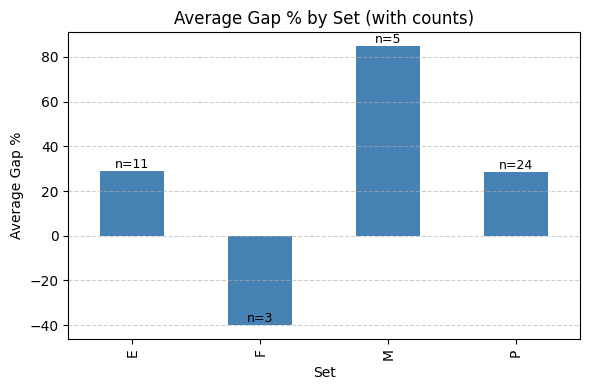

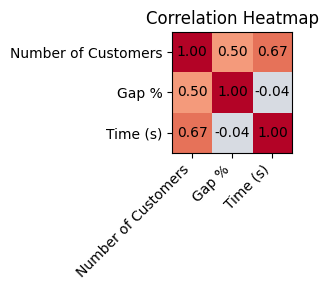

In [55]:
# Enhanced visualizations
if results_df.empty:
    print("No results to visualize. Run the experiment cell first.")
else:
    # Ensure numeric types
    results_df["Gap %"] = pd.to_numeric(results_df["Gap %"], errors="coerce")
    results_df["Time (s)"] = pd.to_numeric(results_df["Time (s)"], errors="coerce")

    # 1) Gap % vs. problem size with trend line (numpy polyfit)
    plt.figure(figsize=(8, 5))
    x = results_df["Number of Customers"].values
    y = results_df["Gap %"].values
    plt.scatter(x, y, alpha=0.7)
    if len(x) > 1:
        coef = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ys = coef[0] * xs + coef[1]
        plt.plot(xs, ys, color="red", linewidth=2, label="Trend")
        plt.legend()
    plt.xlabel("Number of Customers")
    plt.ylabel("Gap %")
    plt.title("Gap % vs. Problem Size")
    plt.grid(True)
    plt.show()

    # 2) Runtime distribution by set (boxplot)
    plt.figure(figsize=(7, 4))
    sets = sorted(results_df["Set"].dropna().unique())
    data = [results_df[results_df["Set"] == s]["Time (s)"].dropna().values for s in sets]
    plt.boxplot(data, labels=sets, patch_artist=True)
    plt.xlabel("Set")
    plt.ylabel("Time (s)")
    plt.title("Runtime Distribution by Set")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

    # 3) Average gap vs. set (bar) with count labels
    avg_gap = results_df.groupby("Set")["Gap %"].mean()
    counts = results_df.groupby("Set").size()
    plt.figure(figsize=(6, 4))
    avg_gap.plot(kind="bar", color="steelblue")
    plt.xlabel("Set")
    plt.ylabel("Average Gap %")
    plt.title("Average Gap % by Set (with counts)")
    for i, s in enumerate(avg_gap.index):
        plt.text(i, avg_gap.iloc[i], f"n={counts.get(s, 0)}", ha="center", va="bottom", fontsize=9)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 4) Correlation heatmap (numeric columns) using pandas
    numeric_cols = results_df[["Number of Customers", "Gap %", "Time (s)"]].dropna()
    corr = numeric_cols.corr()
    plt.figure(figsize=(4, 3))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()


## Conclusion

Summarize whether the average gap meets the grading thresholds:
- ≤ 10% for grades 8–10
- ≤ 15% for grades 6–7
- ≤ 20% for grades 5
- ≤ 25% for grades 4


## 5–7 Slide Presentation Outline

1. Problem statement and datasets (E/F/M/P)
2. Algorithm overview (GA + 2-opt) and representation
3. Parameters and stopping criterion
4. Experimental setup and evaluation metric (Gap %)
5. Results: runtime vs size and average gap per set
6. Discussion: dependence on size and set type
7. Conclusion and repository link
